<a href="https://colab.research.google.com/github/Baronlegend27/academic-research-to-financial-freedom/blob/main/papers/Goetzmann%2C%20W.%20N.%2C%20%26%20Kumar%2C%20A.%20(2008).%20Equity%20portfolio%20diversification/Equity_Portfolio_Diversification.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

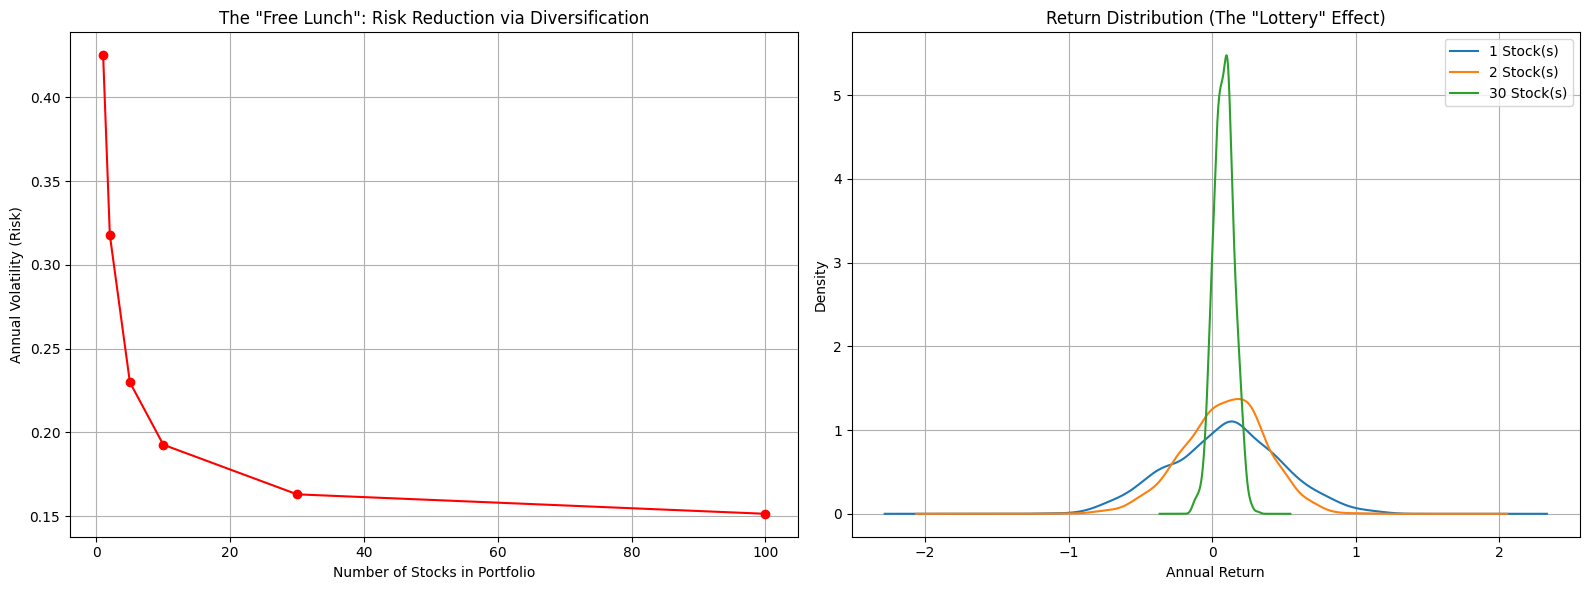

--- Average Outcomes by Portfolio Size ---
        Return       Vol    Sharpe
Size                              
1     0.093191  0.425230  0.169443
2     0.085818  0.317951  0.205124
5     0.078944  0.229864  0.256052
10    0.087474  0.192588  0.350306
30    0.082044  0.162953  0.380458
100   0.080240  0.151330  0.398242


In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# 1. Setup Parameters
np.random.seed(42)
n_stocks = 500
n_days = 252  # One trading year
market_return = 0.08  # 8% Average return
market_volatility = 0.15 # 15% Market-wide risk
idiosyncratic_vol = 0.40 # 40% Individual stock risk (the "noise")

# 2. Simulate Stock Returns
# Each stock has a common market component + a unique random component
common_shock = np.random.normal(market_return/n_days, market_volatility/np.sqrt(n_days), n_days)
stock_returns = []

for i in range(n_stocks):
    unique_shock = np.random.normal(0, idiosyncratic_vol/np.sqrt(n_days), n_days)
    stock_returns.append(common_shock + unique_shock)

stock_returns = np.array(stock_returns)

# 3. Simulate Portfolios
portfolio_sizes = [1, 2, 5, 10, 30, 100]
results = []

for size in portfolio_sizes:
    # Simulate 1000 different investors for each portfolio size
    for _ in range(1000):
        idx = np.random.choice(n_stocks, size, replace=False)
        p_returns = stock_returns[idx].mean(axis=0)

        annual_return = np.sum(p_returns)
        annual_vol = np.std(p_returns) * np.sqrt(n_days)
        sharpe = (annual_return - 0.02) / annual_vol # Assuming 2% risk-free rate

        results.append({'Size': size, 'Return': annual_return, 'Vol': annual_vol, 'Sharpe': sharpe})

df = pd.DataFrame(results)

# 4. Visualization
fig, ax = plt.subplots(1, 2, figsize=(16, 6))

# Plot 1: Risk (Volatility) vs Portfolio Size
# This shows how risk drops off "for free" as you add stocks
df.groupby('Size')['Vol'].mean().plot(kind='line', marker='o', ax=ax[0], color='red')
ax[0].set_title('The "Free Lunch": Risk Reduction via Diversification')
ax[0].set_ylabel('Annual Volatility (Risk)')
ax[0].set_xlabel('Number of Stocks in Portfolio')
ax[0].grid(True)

# Plot 2: Distribution of Returns
# This shows why "average" returns look okay, but the "spread" is dangerous
for size in [1, 2, 30]:
    subset = df[df['Size'] == size]
    subset['Return'].plot(kind='kde', ax=ax[1], label=f'{size} Stock(s)')

ax[1].set_title('Return Distribution (The "Lottery" Effect)')
ax[1].set_xlabel('Annual Return')
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()

# Summary Table
print("--- Average Outcomes by Portfolio Size ---")
print(df.groupby('Size')[['Return', 'Vol', 'Sharpe']].mean())

[*********************100%***********************]  16 of 16 completed


Valid tickers (16): ['AMC', 'BBBY', 'BHP', 'GME', 'HSBC', 'JNJ', 'KLAR', 'NAVN', 'NOK', 'NOW', 'ORCL', 'PLUG', 'RIVN', 'TMUS', 'TTD', 'UNH']
Portfolio sizes: [1, 2, 3, 5, 10, 16]


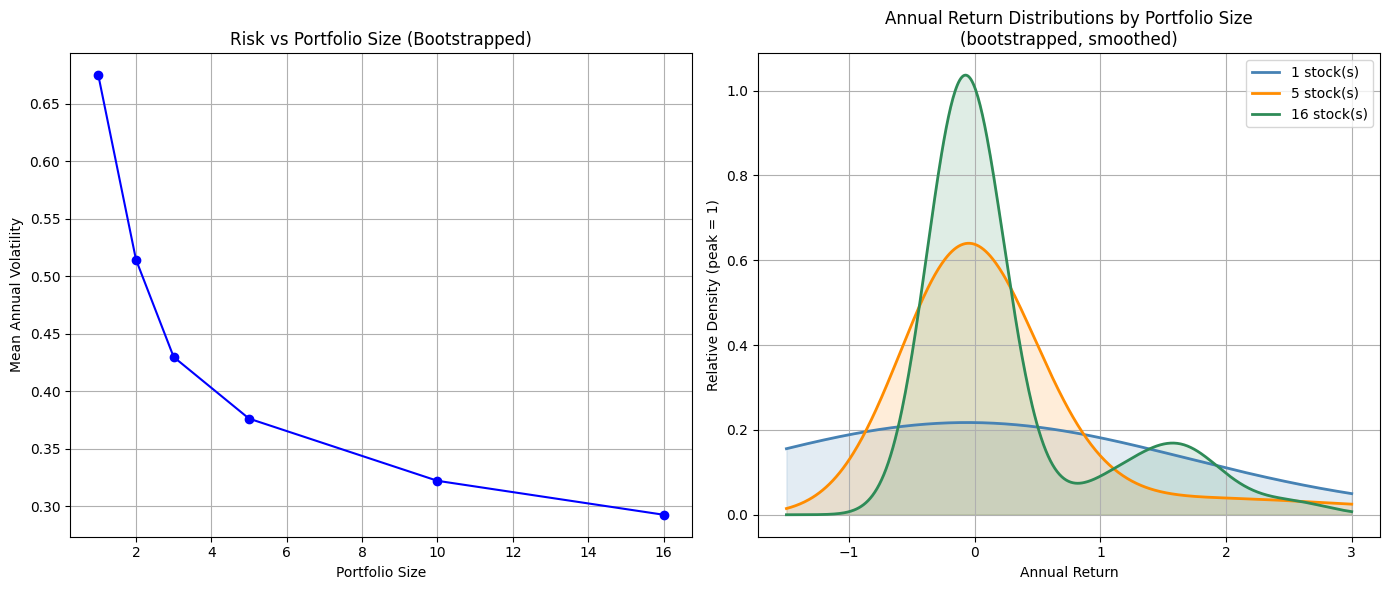

In [2]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import yfinance as yf

tickers = [
    # ── Stable / Blue-chip ───────────────────────────
    "UNH",    # UnitedHealth – healthcare giant
    "JNJ",    # Johnson & Johnson – healthcare/dividend stalwart
    "ORCL",   # Oracle – mature tech, stable
    "BHP",    # BHP Group – commodity giant
    "TMUS",   # T-Mobile US – telecom
    "HSBC",   # HSBC Holdings – international bank

    # ── Medium-risk / Growth ─────────────────────────
    "NOW",    # ServiceNow – growth tech
    "TTD",    # The Trade Desk – adtech, volatile
    "KLAR",   # Klarna (if public) or swap with another fintech ETF
    "NAVN",   # Navan – travel/tech, moderate risk

    # ── High-risk / Volatile ─────────────────────────
    "BBBY",   # Bed Bath & Beyond – bankruptcy 2023
    "PLUG",   # Plug Power – volatile clean energy
    "RIVN",   # Rivian – EV, high volatility/losses
    "AMC",    # AMC Entertainment – meme stock
    "GME",    # GameStop – meme stock
    "NOK"     # Nokia – volatile legacy tech stock, big swings
]

start_date = "2020-01-01"
end_date   = "2025-12-31"

# ── Download ───────────────────────────────────────────────────────────────
price_data = yf.download(tickers, start=start_date, end=end_date, auto_adjust=True)
if isinstance(price_data.columns, pd.MultiIndex):
    price_data = price_data["Close"]

price_data = price_data.dropna(axis=1, how="all")
returns = price_data.pct_change(fill_method=None).dropna(how="all")
returns = returns.dropna(axis=1, how="all")

valid_tickers = returns.columns.tolist()
n_valid = len(valid_tickers)
print(f"Valid tickers ({n_valid}): {valid_tickers}")

if n_valid < 2:
    raise ValueError("Not enough valid tickers.")

# ── Bootstrap short-history stocks ────────────────────────────────────────
# Find the longest common index (full history length)
full_index = returns.index          # all trading days across the whole period
target_len = len(full_index)

bootstrapped = {}
for ticker in valid_tickers:
    col = returns[ticker].dropna()
    actual_len = len(col)

    if actual_len == target_len:
        bootstrapped[ticker] = col.values
    else:
        # How many real days do we have?
        shortage = target_len - actual_len
        # Resample WITH replacement from the ticker's own history to fill the gap
        extra = np.random.choice(col.values, size=shortage, replace=True)
        full_series = np.concatenate([col.values, extra])
        np.random.shuffle(full_series)   # shuffle so bootstrapped days aren't all at the end
        bootstrapped[ticker] = full_series
        #print(f"  Bootstrapped {ticker}: {actual_len} real days → padded to {target_len}")

# Rebuild returns DataFrame from bootstrapped arrays (same index, full length)
returns_boot = pd.DataFrame(bootstrapped, index=full_index)

# ── Portfolio sizes ────────────────────────────────────────────────────────
portfolio_sizes = sorted(set([1, 2, 3, 5, 10, n_valid]) & set(range(1, n_valid + 1)))
print("Portfolio sizes:", portfolio_sizes)

# ── Simulation using rolling 252-day windows ───────────────────────────────
results = []
STEP = 21        # roll forward ~1 month at a time for many overlapping windows

for size in portfolio_sizes:
    for _ in range(500):
        chosen = np.random.choice(valid_tickers, size, replace=False)
        p_returns = returns_boot[chosen].mean(axis=1)

        # Rolling annual windows
        for i in range(0, len(p_returns) - 252, STEP):
            window = p_returns.iloc[i : i + 252]
            annual_return = (1 + window).prod() - 1
            annual_vol    = window.std() * np.sqrt(252)
            sharpe = (annual_return - 0.02) / annual_vol if annual_vol > 0 else np.nan

            results.append({
                "Size":   size,
                "Return": annual_return,
                "Vol":    annual_vol,
                "Sharpe": sharpe
            })

df_real = pd.DataFrame(results)

# ── Plot ───────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(1, 2, figsize=(14, 6))

# Left: Risk vs Portfolio Size
df_real.groupby("Size")["Vol"].mean().plot(
    kind="line", marker="o", ax=ax[0], color="blue"
)
ax[0].set_title("Risk vs Portfolio Size (Bootstrapped)")
ax[0].set_xlabel("Portfolio Size")
ax[0].set_ylabel("Mean Annual Volatility")
ax[0].grid(True)

# Right: KDE with manual bandwidth control via scipy
from scipy.stats import gaussian_kde

kde_sizes = [portfolio_sizes[0], portfolio_sizes[len(portfolio_sizes) // 2], portfolio_sizes[-1]]
colors = ["steelblue", "darkorange", "seagreen"]
x_grid = np.linspace(-1.5, 3.0, 500)

for size, color in zip(kde_sizes, colors):
    subset = df_real[df_real["Size"] == size]["Return"].dropna().values
    if len(subset) > 1:
        # bw_method: Scott's rule * scale factor — increase to smooth more
        kde = gaussian_kde(subset, bw_method="scott")
        kde.set_bandwidth(kde.factor * 3)   # 3× wider bandwidth = smoother
        density = kde(x_grid)


        ax[1].plot(x_grid, density, label=f"{size} stock(s)", color=color, linewidth=2)
        ax[1].fill_between(x_grid, 0, density, alpha=0.15, color=color)

ax[1].set_title("Annual Return Distributions by Portfolio Size\n(bootstrapped, smoothed)")
ax[1].set_xlabel("Annual Return")
ax[1].set_ylabel("Relative Density (peak = 1)")
ax[1].legend()
ax[1].grid(True)

plt.tight_layout()
plt.show()


As portfolio size increases, the mean annual volatility drops steadily, showing that diversification significantly reduces risk. While the average return slightly decreases for larger portfolios, the Sharpe ratio rises, indicating that bigger portfolios trade some upside potential for more stable and more efficient risk-adjusted performance.

In [3]:
# ── Compute distributions for each portfolio size ──
distributions = {}

for size in portfolio_sizes:
    # Get all annual returns for this size
    annual_returns = df_real[df_real["Size"] == size]["Return"].dropna().values
    distributions[size] = annual_returns

# Print a summary
for size, returns in distributions.items():
    print(f"Portfolio Size {size}: {len(returns)} samples, mean={returns.mean():.4f}, std={returns.std():.4f}")

print("\n")

summary = df_real.groupby("Size")[["Return", "Vol", "Sharpe"]].mean()
print("\nMean Annual Stats by Portfolio Size:")
print(summary)

Portfolio Size 1: 30000 samples, mean=0.5986, std=4.4289
Portfolio Size 2: 30000 samples, mean=0.5358, std=2.8598
Portfolio Size 3: 30000 samples, mean=0.3715, std=1.7398
Portfolio Size 5: 30000 samples, mean=0.3460, std=1.2484
Portfolio Size 10: 30000 samples, mean=0.2911, std=0.8666
Portfolio Size 16: 30000 samples, mean=0.2766, std=0.7089



Mean Annual Stats by Portfolio Size:
        Return       Vol    Sharpe
Size                              
1     0.598597  0.674742  0.353784
2     0.535755  0.514433  0.405317
3     0.371463  0.429826  0.372409
5     0.345997  0.376284  0.396692
10    0.291090  0.322250  0.423635
16    0.276646  0.292774  0.501991



The return distribution for a single-stock portfolio is wide and dispersed, showing high variability due to company-specific risk.
As the number of stocks in the portfolio increases, the distribution becomes narrower and more peaked, reflecting the diversification of idiosyncratic risk.
With five stocks, the return outcomes cluster tightly around the average, indicating that more firm-specific volatility has been reduced.
This demonstrates the “lottery effect,” where concentrated portfolios have more extreme outcomes, while diversified portfolios offer more stable returns.


The risk plot illustrates how portfolio volatility decreases as more stocks are added, due to diversification effects.
Volatility drops sharply when moving from very small portfolios to moderately sized ones, capturing the “free lunch” of diversification.
Beyond a certain portfolio size, the risk reduction effect diminishes, approaching the level of systematic market risk that cannot be diversified away.
This aligns with modern portfolio theory, where diversification reduces unsystematic risk, leaving only market-wide risk.


**Tail Risk**

The plot shows that as portfolio size increases, the distribution of annual returns becomes narrower. Smaller portfolios have wider spreads, meaning they can occasionally achieve very high returns but also suffer much larger losses. This illustrates that diversification reduces risk and extreme outcomes, even if it doesn’t guarantee the highest return.

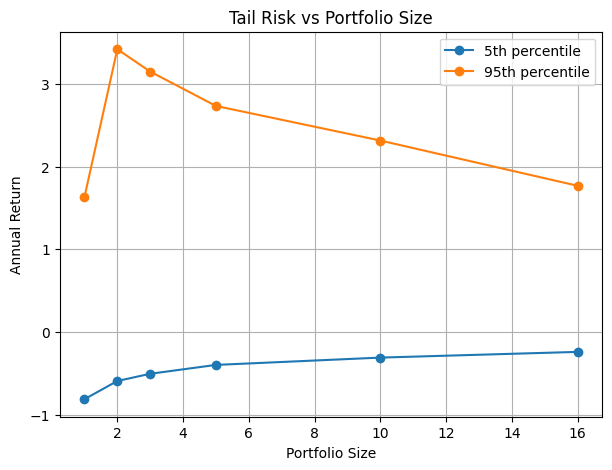

In [4]:
downside = df_real.groupby("Size")["Return"].quantile(0.05)
upside   = df_real.groupby("Size")["Return"].quantile(0.95)

plt.figure(figsize=(7,5))
plt.plot(downside.index, downside.values, marker="o", label="5th percentile")
plt.plot(upside.index, upside.values, marker="o", label="95th percentile")
plt.title("Tail Risk vs Portfolio Size")
plt.xlabel("Portfolio Size")
plt.ylabel("Annual Return")
plt.legend()
plt.grid(True)
plt.show()